# Machine Learning y LLM - Telco Customer Churn

Este notebook entrena modelos de clasificación, evalúa su rendimiento y utiliza un LLM (Groq) para generar una conclusión.

**Modelos:** Regresión Logística, Árbol de Decisión
**LLM:** Groq (llama-3.1-8b-instant)

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, roc_auc_score
)
import os
from dotenv import load_dotenv

## 1. Cargar artefactos preprocesados

In [2]:
preprocessor = joblib.load('../artifacts/preprocessor.pkl')
X_train = joblib.load('../artifacts/X_train.pkl')
X_test = joblib.load('../artifacts/X_test.pkl')
y_train = joblib.load('../artifacts/y_train.pkl')
y_test = joblib.load('../artifacts/y_test.pkl')

print('Artefactos cargados correctamente.')
print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test: {X_test.shape}, y_test: {y_test.shape}')

Artefactos cargados correctamente.
X_train: (5634, 19), y_train: (5634,)
X_test: (1409, 19), y_test: (1409,)


In [3]:
# Aplicar preprocesador
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f'X_train procesado: {X_train_processed.shape}')
print(f'X_test procesado: {X_test_processed.shape}')

X_train procesado: (5634, 30)
X_test procesado: (1409, 30)


## 2. Entrenar modelos

In [4]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42)
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train_processed, y_train)
    trained_models[name] = model
    print(f'{name} entrenado.')

Logistic Regression entrenado.
Decision Tree entrenado.


## 3. Evaluación de modelos

In [5]:
results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test_processed)
    y_proba = model.predict_proba(X_test_processed)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    
    results.append({
        'Modelo': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'AUC': auc
    })
    
    print(f'\n=== {name} ===')
    print(f'Accuracy:  {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall:    {rec:.4f}')
    print(f'F1-Score:  {f1:.4f}')
    print(f'AUC:       {auc:.4f}')
    print(f'\n{classification_report(y_test, y_pred)}')


=== Logistic Regression ===
Accuracy:  0.8055
Precision: 0.6572
Recall:    0.5588
F1-Score:  0.6040
AUC:       0.8420

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


=== Decision Tree ===
Accuracy:  0.7942
Precision: 0.6296
Recall:    0.5455
F1-Score:  0.5845
AUC:       0.8284

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.63      0.55      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



In [6]:
# Tabla comparativa
results_df = pd.DataFrame(results).round(4)
results_df

,Modelo,Accuracy,Precision,Recall,F1-Score,AUC
0,Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8420
1,Decision Tree,0.7942,0.6296,0.5455,0.5845,0.8284


## 4. Matrices de confusión

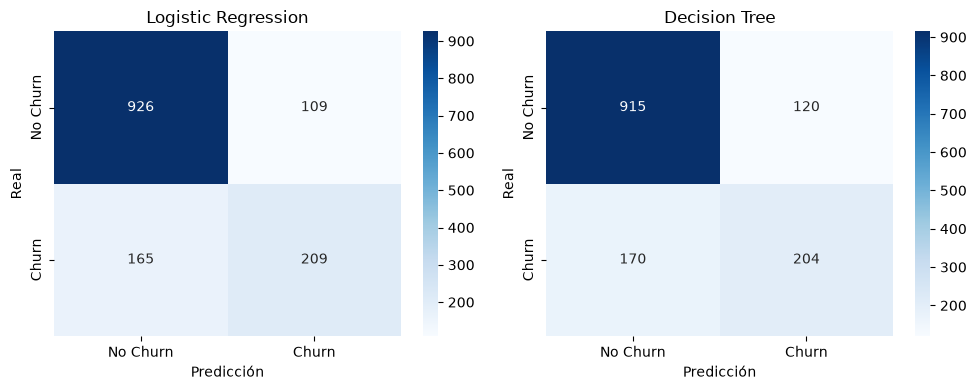

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test_processed)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    ax.set_title(f'{name}')
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.savefig('../artifacts/confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

## 5. Curvas ROC

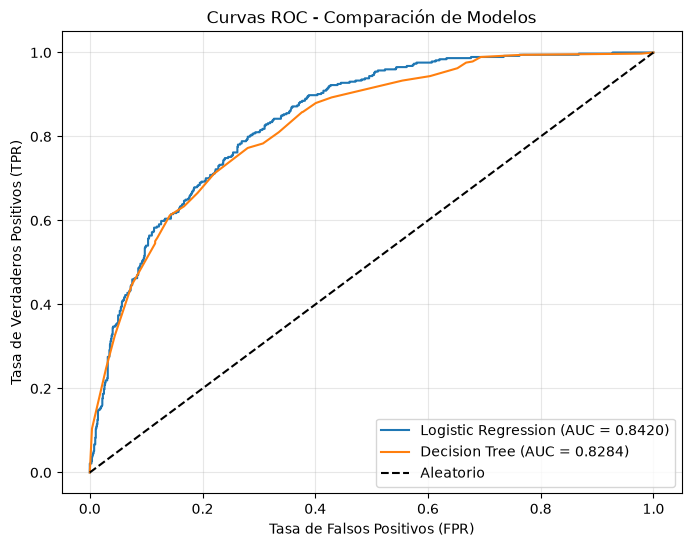

In [8]:
plt.figure(figsize=(8, 6))

for name, model in trained_models.items():
    y_proba = model.predict_proba(X_test_processed)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC - Comparación de Modelos')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.savefig('../artifacts/roc_curves.png', dpi=100, bbox_inches='tight')
plt.show()

## 6. Uso de LLM (Groq) para conclusión

In [9]:
load_dotenv()
api_key = os.getenv('GROQ_API_KEY')

if api_key:
    print('GROQ_API_KEY encontrada.')
else:
    print('GROQ_API_KEY no encontrada en .env')

GROQ_API_KEY encontrada.


In [10]:
if api_key:
    from groq import Groq
    client = Groq(api_key=api_key)
    
    # Usar Logistic Regression como referencia (mejor modelo)
    best_model_name = results_df.loc[results_df['AUC'].idxmax(), 'Modelo']
    best = results_df[results_df['Modelo'] == best_model_name].iloc[0]
    
    prompt = f"""Eres un analista de Machine Learning. Basado en las siguientes métricas de un modelo de clasificación para predicción de churn:

Modelo: {best['Modelo']}
Accuracy: {best['Accuracy']:.4f}
Precision: {best['Precision']:.4f}
Recall: {best['Recall']:.4f}
F1-Score: {best['F1-Score']:.4f}
AUC: {best['AUC']:.4f}

Escribe una conclusión breve de dos párrafos sobre el rendimiento del modelo y recomienda una acción de negocio para reducir el churn. Sé conciso."""
    
    response = client.chat.completions.create(
        model='llama-3.1-8b-instant',
        messages=[{'role': 'user', 'content': prompt}]
    )
    
    llm_conclusion = response.choices[0].message.content
    print('=== CONCLUSIÓN DEL LLM ===')
    print(llm_conclusion)
else:
    llm_conclusion = 'No se pudo conectar con Groq. Verificar API key.'
    print(llm_conclusion)

=== CONCLUSIÓN DEL LLM ===
En general, el modelo de clasificación para la predicción de churn utilizando la técnica de Logistic Regression presenta un buen rendimiento. La precisión en la clasificación es del 80,55%, lo que significa que el modelo es capaz de clasificar correctamente más de cuatro de cada cinco clientes. Además, el AUC (Área Under la Curva) es del 84,20%, lo que indica que el modelo es capaz de distinguir con confianza entre clientes que pueden abandonar la empresa y aquellos que no lo harán.

Sin embargo, la tasa de recuerdo es más baja (55,88%), lo que significa que el modelo podría estar dejando escape a algunos clientes que en realidad pueden abandonar la empresa. Esto sugiere que la empresa podría estar perdiendo clientes que podrían ser recuperados mediante intervenciones adecuadas. En base a estos resultados, recomiendo que la empresa implemente acciones proactivas para fomentar la lealtad de los clientes que están en peligro de abandonar, como ofertas personali

In [11]:
# Clasificar un ejemplo con LLM
if api_key:
    ejemplo = X_test.iloc[0]
    pred = trained_models[best_model_name].predict(X_test_processed[0].reshape(1, -1))[0]
    proba = trained_models[best_model_name].predict_proba(X_test_processed[0].reshape(1, -1))[0]
    
    prompt2 = f"""Dado un cliente con las siguientes características:
{ejemplo.to_dict()}

¿Es probable que este cliente abandone la compañía (churn)?
La predicción del modelo es: {'Sí' if pred == 1 else 'No'} (probabilidad: {proba[pred]:.2f})

Responde solo con un breve análisis de 3-4 líneas."""
    
    response2 = client.chat.completions.create(
        model='llama-3.1-8b-instant',
        messages=[{'role': 'user', 'content': prompt2}]
    )
    
    print('=== ANÁLISIS DEL EJEMPLO ===')
    print(f'Cliente real: {"Churn" if y_test.iloc[0] == 1 else "No Churn"}')
    print(f'Predicción del modelo: {"Churn" if pred == 1 else "No Churn"}')
    print(f'\nComentario del LLM:')
    print(response2.choices[0].message.content)

=== ANÁLISIS DEL EJEMPLO ===
Cliente real: No Churn
Predicción del modelo: No Churn

Comentario del LLM:
Basándome en las características del cliente, no parecen existir factores que indiquen una alta probabilidad de abandono (churn). La existencia de un compañero y dependientes sugiere una situación familiar estable. Además, el alta participación en servicios adicionales como protección de dispositivos y asistencia técnica podría estar relacionada con una gran lealtad al servicio.


## 7. Guardar modelos entrenados

In [12]:
joblib.dump(trained_models['Logistic Regression'], '../artifacts/logistic_model.pkl')
joblib.dump(trained_models['Decision Tree'], '../artifacts/tree_model.pkl')

print('Modelos guardados en artifacts/:')
for f in ['logistic_model.pkl', 'tree_model.pkl']:
    path = f'../artifacts/{f}'
    size = os.path.getsize(path) / 1024
    print(f'  {f} - {size:.1f} KB')

Modelos guardados en artifacts/:
  logistic_model.pkl - 1.1 KB
  tree_model.pkl - 6.2 KB
